[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/notebooks/EN/chapter14_lecture_notebook.ipynb)

# Time Series Analysis — Chapter 14: Multivariate GARCH models

*Lecture notebook (self-study chapter). Daniel Traian Pele, Bucharest University of Economic Studies.*

- Why multivariate volatility: portfolio risk, hedging, contagion; rolling correlations; asynchronous trading.
- The number of parameters of VEC, BEKK, CCC and DCC models.
- DCC (Engle 2002) in two steps: a GARCH(1,1) per series, then the correlation parameters $(a, b)$; the test against constant correlation (CCC, Bollerslev 1990); the crises of 2008 and 2020.
- A five-asset DCC: S&P 500, DAX, BET, EUR/RON, Bitcoin.
- Applications: portfolio VaR 1% with backtesting (Kupiec, Christoffersen) and dynamic hedge ratios.
- The first code cell installs the `arch` package if it is missing; without it a numpy GARCH estimator is used.
- References: Bollerslev, Engle and Wooldridge (1988); Bollerslev (1990); Engle and Kroner (1995); Engle (2002); Kroner and Sultan (1993); Kupiec (1995); Christoffersen (1998).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_14'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/TSA - Serii de timp/repo/notebooks/EN


In [2]:
# The arch package (step 1: univariate GARCH) is not preinstalled in Google Colab: pip install arch
# (without it, garch11_fit falls back to a numpy maximum-likelihood estimator)
import importlib.util, subprocess, sys
if importlib.util.find_spec('arch') is None:
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'arch'])
    except Exception as e:
        print('arch not installed, the numpy fallback will be used:', e)

In [3]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [4]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the TSA repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [5]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Definitions and helpers used in the whole notebook

- `common_returns(names, start)`: daily log returns in % on the days on which all markets trade.
- `garch11_fit(r)`, `garch11_filter(r, p)`: step 1, a GARCH(1,1) per series (one-step-ahead volatility, standardised residuals).
- `dcc_path(Z, a, b, Qbar)`: the correlation matrices $\mathbf{R}_t$; `dcc_loglik`, `dcc_fit`: step 2 by maximum likelihood with correlation targeting ($\bar{\mathbf{Q}}$ = sample correlation of $\mathbf{z}_t$).
- The `arch` package has no DCC model: step 2 is written out here in a few lines of numpy.

In [6]:
from scipy.signal import lfilter
NAME = {'sp500': 'S&P 500', 'dax': 'DAX', 'bet': 'BET', 'eurron': 'EUR/RON', 'btc': 'Bitcoin'}
PANEL = ['sp500', 'dax', 'bet', 'eurron', 'btc']
PANEL_START = '2015-01-01'
PAIR_START = '2000-01-01'
HEDGE_START = '2005-01-01'
SPLIT = '2014-12-31'
ROLL = 250
ALPHA_VAR = 0.01
WEIGHTS = (0.5, 0.5)
CRISES = {'2008': ('2008-09-15', '2009-03-31'), '2020': ('2020-02-20', '2020-04-30')}
CALM = ('2017-01-01', '2019-12-31')
PANEL_CRISIS = ('2020-02-14', '2020-06-30')
EX = {'s1': 20.0, 's2': 20.0, 'rhos': (0.2, 0.8), 'a': 0.05, 'b': 0.93, 'qbar': 0.5, 'q11': 1.0, 'q22': 1.0, 'q12': 0.5, 'z': (-2.0, -2.5), 'var_s': (1.5, 1.2), 'var_rho': (0.3, 0.9), 'h_ss': 1.2, 'h_sf': 1.0, 'h_rho': 0.8, 'bk': {'c12': 0.02, 'a11': 0.3, 'a22': 0.25, 'b11': 0.94, 'b22': 0.95, 'e': (-2.0, -1.5), 'h12': 0.5}}
COLORS = {'sp500': st.MainBlue, 'dax': st.Teal, 'bet': st.IDAred, 'eurron': st.Forest, 'btc': st.Amber}
HERE = "."


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def shade(ax, periods=CRISES, alpha=0.15):
    for i, (a, b) in enumerate(periods.values()):
        ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color=st.Crimson, alpha=alpha, lw=0,
                   label='Crisis periods (2008, 2020)' if i == 0 else None)


def common_returns(names, start, end=None):
    """Daily log returns in % computed on the days on which ALL markets trade: prices are aligned first, so each
    return covers the same calendar interval for every series."""
    P = pd.concat([load_close(k, start) for k in names], axis=1, join='inner')
    if end:
        P = P.loc[:end]
    return (100 * np.log(P).diff()).dropna()


def weekly_returns(names, start=PANEL_START):
    """Weekly log returns in % (Friday closes, or the last close of the week): the weekly horizon removes most of the
    asynchronous-trading problem of markets that close at different hours (New York, Frankfurt, Bucharest, crypto)."""
    P = pd.concat([load_close(k, start).resample('W-FRI').last() for k in names], axis=1).dropna()
    return (100 * np.log(P).diff()).dropna()


def garch11_negloglik(theta, r):
    """Gaussian negative log-likelihood of r_t = mu + e_t, sigma2_t = omega + alpha e_{t-1}^2 + beta sigma2_{t-1}."""
    mu, omega, alpha, beta = theta
    if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= 0.9999:
        return 1e10
    e = r - mu
    s2 = garch11_variance(e, omega, alpha, beta)
    return 0.5 * np.sum(np.log(2 * np.pi) + np.log(s2) + e ** 2 / s2)


def garch11_variance(e, omega, alpha, beta, s0=None):
    """sigma2_t = omega + alpha e_{t-1}^2 + beta sigma2_{t-1}, started at the sample variance (one-step-ahead:
    sigma2_t uses only e_1, ..., e_{t-1})."""
    x = np.empty(len(e))
    x[0] = np.var(e) if s0 is None else s0
    x[1:] = omega + alpha * e[:-1] ** 2
    # sigma2_t - beta sigma2_{t-1} = x_t  -> a linear filter
    out = lfilter([1.0], [1.0, -beta], x)
    return out


def garch11_fit(r):
    """Step 1 of DCC: GARCH(1,1) with a constant mean, Gaussian QML. The arch package if installed, else a numpy
    maximum-likelihood fallback (the two give practically the same estimates)."""
    r = np.asarray(r, float)
    try:
        from arch import arch_model
        res = arch_model(r, mean='Constant', vol='GARCH', p=1, q=1, dist='normal').fit(disp='off')
        p = res.params
        return dict(mu=float(p['mu']), omega=float(p['omega']), alpha=float(p['alpha[1]']), beta=float(p['beta[1]']))
    except ImportError:
        v = np.var(r)
        best = optimize.minimize(garch11_negloglik, [r.mean(), 0.05 * v, 0.08, 0.90], args=(r,), method='Nelder-Mead',
                                 options=dict(maxiter=4000, xatol=1e-8, fatol=1e-8))
        mu, omega, alpha, beta = best.x
        return dict(mu=float(mu), omega=float(omega), alpha=float(alpha), beta=float(beta))


def garch11_filter(r, p, s0=None):
    """Conditional volatility (one step ahead) and standardised residuals z_t = (r_t - mu) / sigma_t for given
    parameters p (from garch11_fit), on any sample (also out of sample)."""
    e = np.asarray(r, float) - p['mu']
    s2 = garch11_variance(e, p['omega'], p['alpha'], p['beta'], s0)
    s = np.sqrt(s2)
    return s, e / s


def step1(R, fit_until=None):
    """GARCH(1,1) for every column of R (estimated on R.loc[:fit_until]); volatilities and residuals on all of R."""
    P, S, Z = {}, {}, {}
    for c in R.columns:
        x = R[c].loc[:fit_until] if fit_until else R[c]
        P[c] = garch11_fit(x.values)
        s0 = float(np.var(x.values - P[c]['mu']))
        S[c], Z[c] = garch11_filter(R[c].values, P[c], s0)
    return P, pd.DataFrame(S, index=R.index), pd.DataFrame(Z, index=R.index)


def dcc_path(Z, a, b, Qbar=None):
    """Correlation matrices R_t (T x N x N), one step ahead (R_t uses z_1, ..., z_{t-1}). Every element of Q_t follows
    the same linear recursion, computed with scipy's lfilter."""
    X = np.asarray(Z, float)
    T, N = X.shape
    Qbar = np.corrcoef(X.T) if Qbar is None else Qbar
    P = np.einsum('ti,tj->tij', X, X)                       # z_t z_t'
    drive = np.empty_like(P)
    drive[0] = Qbar
    drive[1:] = (1 - a - b) * Qbar + a * P[:-1]
    Q = lfilter([1.0], [1.0, -b], drive.reshape(T, -1), axis=0).reshape(T, N, N)
    Q[0] = Qbar
    d = np.sqrt(np.einsum('tii->ti', Q))
    return Q / (d[:, :, None] * d[:, None, :])


def dcc_loglik(Z, a, b, Qbar=None):
    """Correlation part of the Gaussian log-likelihood: -1/2 sum_t (log|R_t| + z_t' R_t^{-1} z_t - z_t' z_t)."""
    X = np.asarray(Z, float)
    R = dcc_path(X, a, b, Qbar)
    _, logdet = np.linalg.slogdet(R)
    quad = np.einsum('ti,tij,tj->t', X, np.linalg.inv(R), X)
    return float(-0.5 * np.sum(logdet + quad - np.sum(X ** 2, axis=1)))


def num_hessian(f, x, h=1e-4):
    k = len(x)
    H = np.zeros((k, k))
    E = np.eye(k) * h
    for i in range(k):
        for j in range(k):
            H[i, j] = (f(x + E[i] + E[j]) - f(x + E[i] - E[j]) - f(x - E[i] + E[j]) + f(x - E[i] - E[j])) / (4 * h * h)
    return H


def dcc_fit(Z):
    """Step 2: (a, b) by maximum likelihood with Qbar fixed at the sample correlation of z (correlation targeting).
    Standard errors from the step-2 Hessian (they ignore the estimation error of step 1). CCC: a = b = 0."""
    X = np.asarray(Z, float)
    Qbar = np.corrcoef(X.T)

    def nll(p):
        a, b = p
        if a < 0 or b < 0 or a + b >= 0.9999:
            return 1e10
        return -dcc_loglik(X, a, b, Qbar)

    best = None
    for s in ((0.03, 0.95), (0.01, 0.98), (0.05, 0.90), (0.10, 0.80)):
        r = optimize.minimize(nll, s, method='Nelder-Mead', options=dict(xatol=1e-7, fatol=1e-7, maxiter=4000))
        if best is None or r.fun < best.fun:
            best = r
    a, b = best.x
    try:
        se = np.sqrt(np.diag(np.linalg.inv(num_hessian(nll, best.x))))
    except Exception:
        se = np.array([np.nan, np.nan])
    ll, ll0 = -best.fun, dcc_loglik(X, 0.0, 0.0, Qbar)
    return dict(a=float(a), b=float(b), se_a=float(se[0]), se_b=float(se[1]), loglik=float(ll), ccc_loglik=float(ll0),
                lr=float(2 * (ll - ll0)), Qbar=Qbar)


def half_life(p):
    return float(np.log(0.5) / np.log(p))

## 1. Why multivariate volatility

- The worked examples of the slides; diversification against the correlation; rolling correlations; the asynchronous closes of 9-10 April 2025.

{'div': {'0.2': 15.491933384829668, '0.8': 18.973665961010276}, 'dcc': {'c': 0.019999999999999907, 'q11': 1.15, 'q22': 1.2625, 'q12': 0.725, 'rho': 0.6016908303767384, 't1': 0.009999999999999953, 't2': 0.25, 't3': 0.465}, 'var': {'z': -2.3263478740408408, '0.3': {'sp': 1.0920164833920778, 'var': 2.540410224556715}, '0.9': {'sp': 1.3162446581088183, 'var': 3.0620429621090626}}, 'hedge': {'h': 0.96, 'cov': 0.96, 'he': 0.6400000000000001, 'sd_hedged': 0.7199999999999999}, 'bekk': {'aa': 0.075, 'bb': 0.8929999999999999, 'ee': 3.0, 't1': 0.02, 't2': 0.22499999999999998, 't3': 0.44649999999999995, 'h12': 0.6914999999999999}}


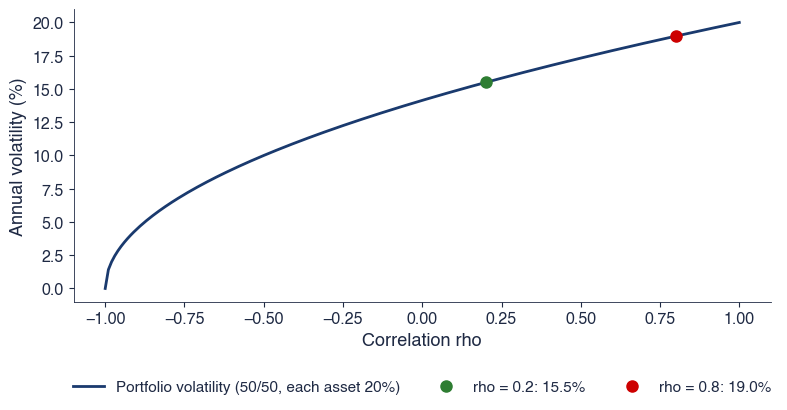

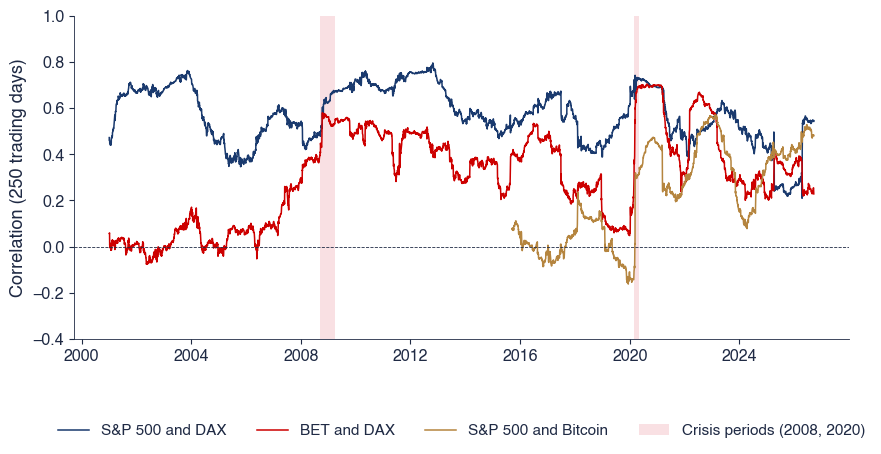

{'sp500_dax': {'min': 0.20895569923594606, 'max': 0.7950756055807339, 'dmin': '2026-04-14', 'dmax': '2012-10-25', 'last': 0.5421556047272665, 'full': 0.5989634409609766, 'n': 6605}, 'bet_dax': {'min': -0.07653258914174106, 'max': 0.7037594747520223, 'dmin': '2002-05-28', 'dmax': '2020-08-17', 'last': 0.22810829589107187, 'full': 0.30577257582865125, 'n': 6608}, 'sp500_btc': {'min': -0.16223371438284048, 'max': 0.5705525534112216, 'dmin': '2019-12-12', 'dmax': '2023-02-09', 'last': 0.47985289839796264, 'full': 0.23728459085855488, 'n': 3017}}
{'2025-04-02': [0.6705663111373994, -0.6638674644314335], '2025-04-03': [-4.960591283072979, -3.0538624556079697], '2025-04-04': [-6.160905396787442, -5.079905162473075], '2025-04-07': [-0.23341989170884148, -4.215671266152299], '2025-04-08': [-1.582508719681286, 2.4490441340478952], '2025-04-09': [9.089488332329232, -3.0508629573406054], '2025-04-10': [-3.522060748440836, 4.434084429315455], '2025-04-11': [1.793038857179674, -0.9215727501185711]}


In [7]:
def worked_examples():
    """Numbers of the worked examples: diversification, one DCC step, a two-asset VaR 1%, a hedge ratio."""
    e = EX
    w = np.array(WEIGHTS)
    div = {}
    for rho in e['rhos']:
        v = (w[0] * e['s1']) ** 2 + (w[1] * e['s2']) ** 2 + 2 * w[0] * w[1] * rho * e['s1'] * e['s2']
        div[str(rho)] = float(np.sqrt(v))
    z1, z2 = e['z']
    c = 1 - e['a'] - e['b']
    q11 = c * 1.0 + e['a'] * z1 * z1 + e['b'] * e['q11']
    q22 = c * 1.0 + e['a'] * z2 * z2 + e['b'] * e['q22']
    q12 = c * e['qbar'] + e['a'] * z1 * z2 + e['b'] * e['q12']
    dcc = dict(c=c, q11=q11, q22=q22, q12=q12, rho=q12 / np.sqrt(q11 * q22),
               t1=c * e['qbar'], t2=e['a'] * z1 * z2, t3=e['b'] * e['q12'])
    zq = float(stats.norm.ppf(ALPHA_VAR))
    var = {'z': zq}
    s1, s2 = e['var_s']
    for rho in e['var_rho']:
        sp = np.sqrt((w[0] * s1) ** 2 + (w[1] * s2) ** 2 + 2 * w[0] * w[1] * rho * s1 * s2)
        var[str(rho)] = dict(sp=float(sp), var=float(-zq * sp))
    h = e['h_rho'] * e['h_ss'] / e['h_sf']
    hed = dict(h=h, cov=e['h_rho'] * e['h_ss'] * e['h_sf'], he=e['h_rho'] ** 2,
               sd_hedged=float(e['h_ss'] * np.sqrt(1 - e['h_rho'] ** 2)))
    k = e['bk']
    t1, t2, t3 = k['c12'], k['a11'] * k['a22'] * k['e'][0] * k['e'][1], k['b11'] * k['b22'] * k['h12']
    bekk = dict(aa=k['a11'] * k['a22'], bb=k['b11'] * k['b22'], ee=k['e'][0] * k['e'][1], t1=t1, t2=t2, t3=t3, h12=t1 + t2 + t3)
    return dict(div=div, dcc={k: float(v) for k, v in dcc.items()}, var=var, hedge={k: float(v) for k, v in hed.items()},
                bekk={k: float(v) for k, v in bekk.items()})


def fig_diversification(save_it=True):
    """Volatility of a 50/50 portfolio of two assets with 20% volatility each, as a function of the correlation."""
    rho = np.linspace(-1, 1, 201)
    s = EX['s1']
    sp = np.sqrt(0.25 * s ** 2 * 2 + 2 * 0.25 * rho * s * s)
    fig, ax = plt.subplots(figsize=(9, 3.8))
    ax.plot(rho, sp, color=st.MainBlue, lw=2, label='Portfolio volatility (50/50, each asset 20%)')
    for r0, c in zip(EX['rhos'], (st.Forest, st.IDAred)):
        v = np.sqrt(0.5 * s ** 2 + 0.5 * r0 * s * s)
        ax.plot([r0], [v], 'o', color=c, ms=8, label=f'rho = {r0}: {v:.1f}%')
    ax.set_xlabel('Correlation rho')
    ax.set_ylabel('Annual volatility (%)')
    st.legend_outside_bottom(ax, ncol=3)
    save('tsa_ch14_diversification', save_it)
    return {}


def fig_rolling_corr(save_it=True):
    """Rolling 250-day correlations of daily returns on common trading days."""
    pairs = [('sp500', 'dax'), ('bet', 'dax'), ('sp500', 'btc')]
    cols = [st.MainBlue, st.IDAred, st.Amber]
    out = {}
    fig, ax = plt.subplots(figsize=(10, 4.2))
    for (x, y), c in zip(pairs, cols):
        R = common_returns([x, y], PAIR_START if y != 'btc' else '2014-09-17')
        rc = R[x].rolling(ROLL).corr(R[y]).dropna()
        ax.plot(rc.index, rc, color=c, lw=1.1, label=f'{NAME[x]} and {NAME[y]}')
        out[f'{x}_{y}'] = dict(min=float(rc.min()), max=float(rc.max()), dmin=str(rc.idxmin().date()),
                               dmax=str(rc.idxmax().date()), last=float(rc.iloc[-1]), full=float(R.corr().iloc[0, 1]),
                               n=len(R))
    R = common_returns(['sp500', 'dax'], '2025-04-01', '2025-04-11')     # the tariff shock of April 2025
    out['apr2025'] = {str(d.date()): [float(R.loc[d, 'sp500']), float(R.loc[d, 'dax'])] for d in R.index}
    shade(ax)
    ax.axhline(0, color=st.DarkText, lw=0.6, ls='--')
    ax.set_ylabel('Correlation (250 trading days)')
    ax.set_ylim(-0.4, 1.0)
    st.legend_outside_bottom(ax, ncol=4)
    save('tsa_ch14_rolling_corr', save_it)
    return out


print(worked_examples())
fig_diversification(save_it=False)
rc = fig_rolling_corr(save_it=False)
print({k: v for k, v in rc.items() if k != 'apr2025'})
print(rc['apr2025'])

## 2. The number of parameters

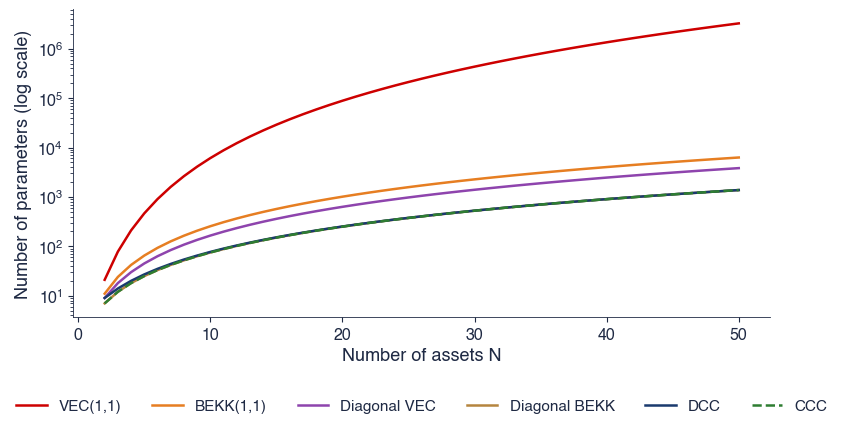

        2    5    10       50
VEC    21  465  6105  3252525
DVEC    9   45   165     3825
BEKK   11   65   255     6275
DBEKK   7   25    75     1375
SBEKK   5   17    57     1277
CCC     7   25    75     1375
DCC     9   27    77     1377


In [8]:
def n_params(N):
    k = N * (N + 1) // 2
    return {'VEC': k + 2 * k * k, 'DVEC': 3 * k, 'BEKK': k + 2 * N * N, 'DBEKK': k + 2 * N, 'SBEKK': k + 2,
            'CCC': 3 * N + N * (N - 1) // 2, 'DCC': 3 * N + N * (N - 1) // 2 + 2}


def fig_param_count(save_it=True):
    Ns = np.arange(2, 51)
    lab = {'VEC': 'VEC(1,1)', 'BEKK': 'BEKK(1,1)', 'DVEC': 'Diagonal VEC', 'DBEKK': 'Diagonal BEKK', 'DCC': 'DCC',
           'CCC': 'CCC'}
    cols = {'VEC': st.IDAred, 'BEKK': st.Orange, 'DVEC': st.Purple, 'DBEKK': st.Amber, 'DCC': st.MainBlue, 'CCC': st.Forest}
    fig, ax = plt.subplots(figsize=(9, 4))
    for m in lab:
        ax.plot(Ns, [n_params(n)[m] for n in Ns], color=cols[m], lw=1.8, ls='--' if m == 'CCC' else '-', label=lab[m])
    ax.set_yscale('log')
    ax.set_xlabel('Number of assets N')
    ax.set_ylabel('Number of parameters (log scale)')
    st.legend_outside_bottom(ax, ncol=6)
    save('tsa_ch14_param_count', save_it)
    return {str(n): n_params(n) for n in (2, 5, 10, 50)}


print(pd.DataFrame(fig_param_count(save_it=False)))

## 3. DCC for the S&P 500 and the DAX

- Step 1: GARCH(1,1) for each index; step 2: $(a, b)$; LR test against CCC; the crises of 2008 and 2020.

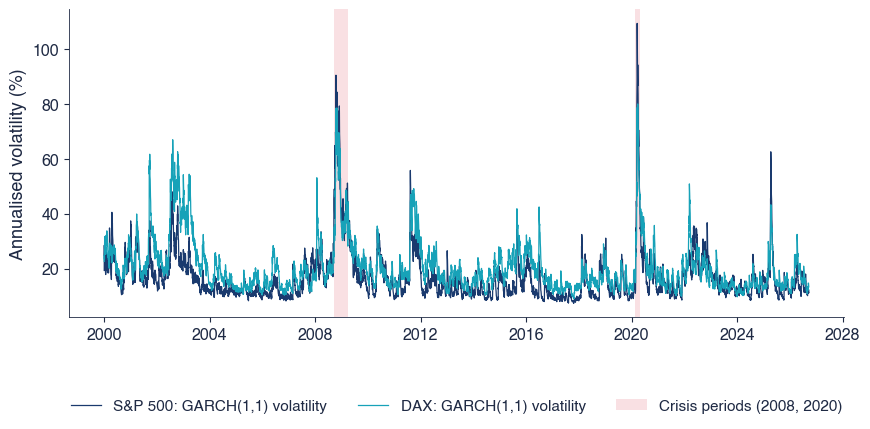

{'n': 6605, 'first': '2000-01-04', 'last': '2026-09-18', 'sp500': {'mu': 0.06290565567703757, 'omega': 0.02675939289447576, 'alpha': 0.12240558144302205, 'beta': 0.8572490659436869, 'pers': 0.9796546473867089, 'vmax': 109.34673296542309, 'dmax': '2020-03-17', 'zstd': 0.9998114028161961, 'zkurt': 1.7588727277319656, 'rkurt': 10.544139242544006}, 'dax': {'mu': 0.06747853500259957, 'omega': 0.030198594497266928, 'alpha': 0.09832609123521734, 'beta': 0.8859178062710064, 'pers': 0.9842438975062237, 'vmax': 80.00335067700694, 'dmax': '2020-03-25', 'zstd': 0.9998799736221757, 'zkurt': 1.3594068993578006, 'rkurt': 6.237488732416638}, 'zcorr': 0.5748417597853523, 'rcorr': 0.5989634409609766}


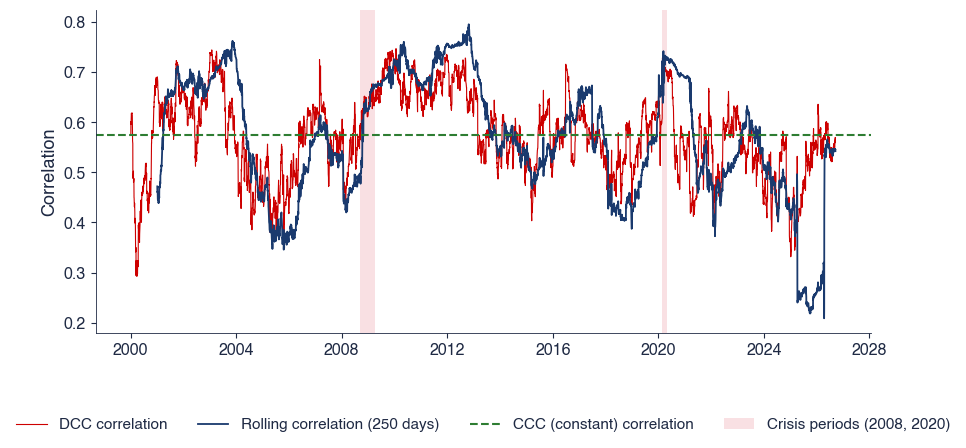

{'a': 0.0152, 'b': 0.9766, 'se_a': 0.0035, 'se_b': 0.0065, 'ab': 0.9918, 'hl': 84.6363, 'll': 1395.4705, 'll0': 1329.5797, 'lr': 131.7818, 'crit': 5.9915, 'qbar': 0.5748, 'min': 0.2927, 'dmin': '2000-03-27', 'max': 0.7465, 'dmax': '2010-01-22', 'mean': 0.5731, 'last': 0.5649, 'lastd': '2026-09-18', 'sd_dcc': 0.0832, 'sd_roll': 0.1224, 'mean_2008': 0.6334, 'vol_2008': 51.3926, 'mean_2020': 0.6952, 'vol_2020': 57.828, 'mean_calm': 0.5566, 'vol_calm': 12.6336}


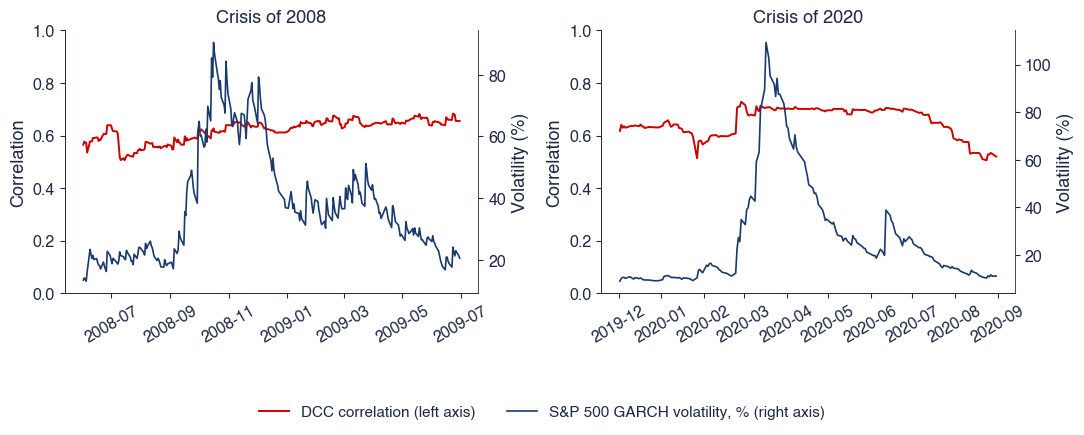

{'2008': {'rmax': 0.6832760147207293, 'rdmax': '2009-06-23', 'r0': 0.5653136840188084, 'vmax': 90.47636095348432, 'vdmax': '2008-10-16'}, '2020': {'rmax': 0.7281862468402359, 'rdmax': '2020-02-28', 'r0': 0.6177907279488876, 'vmax': 109.34673296542309, 'vdmax': '2020-03-17'}}


In [9]:
def dcc_sp_dax():
    R = common_returns(['sp500', 'dax'], PAIR_START)
    P, S, Z = step1(R)
    f = dcc_fit(Z.values)
    Rt = dcc_path(Z.values, f['a'], f['b'], f['Qbar'])
    rho = pd.Series(Rt[:, 0, 1], index=R.index)
    return R, P, S, Z, f, rho


def fig_step1(save_it=True):
    R, P, S, Z, f, rho = dcc_sp_dax()
    fig, ax = plt.subplots(figsize=(10, 4))
    for k in ('sp500', 'dax'):
        ax.plot(S.index, S[k] * np.sqrt(252), color=COLORS[k], lw=0.9, label=f'{NAME[k]}: GARCH(1,1) volatility')
    shade(ax)
    ax.set_ylabel('Annualised volatility (%)')
    st.legend_outside_bottom(ax, ncol=3)
    save('tsa_ch14_garch_step1', save_it)
    out = {'n': len(R), 'first': str(R.index[0].date()), 'last': str(R.index[-1].date())}
    for k in ('sp500', 'dax'):
        out[k] = dict(P[k], pers=P[k]['alpha'] + P[k]['beta'], vmax=float(S[k].max() * np.sqrt(252)),
                      dmax=str(S[k].idxmax().date()), zstd=float(Z[k].std()), zkurt=float(stats.kurtosis(Z[k])),
                      rkurt=float(stats.kurtosis(R[k])))
    out['zcorr'] = float(Z.corr().iloc[0, 1])
    out['rcorr'] = float(R.corr().iloc[0, 1])
    return out


def fig_dcc_sp_dax(save_it=True):
    R, P, S, Z, f, rho = dcc_sp_dax()
    roll = R['sp500'].rolling(ROLL).corr(R['dax'])
    fig, ax = plt.subplots(figsize=(10, 4.2))
    ax.plot(rho.index, rho, color=st.IDAred, lw=0.8, label='DCC correlation')
    ax.plot(roll.index, roll, color=st.MainBlue, lw=1.3, label='Rolling correlation (250 days)')
    ax.axhline(f['Qbar'][0, 1], color=st.Forest, lw=1.5, ls='--', label='CCC (constant) correlation')
    shade(ax)
    ax.set_ylabel('Correlation')
    st.legend_outside_bottom(ax, ncol=4)
    save('tsa_ch14_dcc_sp_dax', save_it)
    out = dict(a=f['a'], b=f['b'], se_a=f['se_a'], se_b=f['se_b'], ab=f['a'] + f['b'], hl=half_life(f['a'] + f['b']),
               ll=f['loglik'], ll0=f['ccc_loglik'], lr=f['lr'], crit=float(stats.chi2.ppf(0.95, 2)), qbar=float(f['Qbar'][0, 1]),
               min=float(rho.min()), dmin=str(rho.idxmin().date()), max=float(rho.max()), dmax=str(rho.idxmax().date()),
               mean=float(rho.mean()), last=float(rho.iloc[-1]), lastd=str(rho.index[-1].date()),
               sd_dcc=float(rho.std()), sd_roll=float(roll.std()))
    for k, (a, b) in dict(CRISES, calm=CALM).items():
        out[f'mean_{k}'] = float(rho.loc[a:b].mean())
        out[f'vol_{k}'] = float(S.loc[a:b, 'sp500'].mean() * np.sqrt(252))
    return out


def fig_crisis_zoom(save_it=True):
    R, P, S, Z, f, rho = dcc_sp_dax()
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    win = {'2008': ('2008-06-01', '2009-06-30'), '2020': ('2019-12-01', '2020-08-31')}
    out = {}
    for ax, (k, (a, b)) in zip(axes, win.items()):
        r = rho.loc[a:b]
        v = (S.loc[a:b, 'sp500'] * np.sqrt(252))
        ax.plot(r.index, r, color=st.IDAred, lw=1.4, label='DCC correlation (left axis)')
        ax.set_ylim(0, 1)
        ax.set_ylabel('Correlation')
        ax2 = ax.twinx()
        ax2.plot(v.index, v, color=st.MainBlue, lw=1.2, label='S&P 500 GARCH volatility, % (right axis)')
        ax2.set_ylabel('Volatility (%)')
        ax2.spines['right'].set_visible(True)
        ax.set_title(f'Crisis of {k}')
        ax.tick_params(axis='x', labelrotation=30)
        out[k] = dict(rmax=float(r.max()), rdmax=str(r.idxmax().date()), r0=float(r.iloc[0]), vmax=float(v.max()),
                      vdmax=str(v.idxmax().date()))
    h1, l1 = axes[0].get_legend_handles_labels()
    h2, l2 = axes[0].get_figure().axes[2].get_legend_handles_labels()
    st.fig_legend_bottom(fig, h1 + h2, l1 + l2, ncol=2, y=0.0)
    plt.tight_layout(rect=(0, 0.07, 1, 1))
    save('tsa_ch14_crisis_zoom', save_it)
    return out


print(fig_step1(save_it=False))
d = fig_dcc_sp_dax(save_it=False)
print({k: round(v, 4) if isinstance(v, float) else v for k, v in d.items()})
print(fig_crisis_zoom(save_it=False))

### Check: does the code recover known parameters?

- Simulate two series with a DCC correlation ($a = 0.04$, $b = 0.94$, $\bar\rho = 0.5$) and unit variances, then estimate $(a, b)$ by step 2.

In [10]:
rng = np.random.default_rng(2026)
T, a0, b0, rho0 = 3000, 0.04, 0.94, 0.5
Qbar = np.array([[1, rho0], [rho0, 1]])
Q, Zs = Qbar.copy(), np.empty((T, 2))
for t in range(T):
    d = np.sqrt(np.diag(Q))
    R = Q / np.outer(d, d)
    Zs[t] = np.linalg.cholesky(R) @ rng.standard_normal(2)
    Q = (1 - a0 - b0) * Qbar + a0 * np.outer(Zs[t], Zs[t]) + b0 * Q
f = dcc_fit(Zs)
print('true a, b:', a0, b0, '  estimated:', round(f['a'], 4), round(f['b'], 4), '  SE:', round(f['se_a'], 4), round(f['se_b'], 4))

true a, b: 0.04 0.94   estimated: 0.0344 0.9128   SE: 0.008 0.0221


## 4. Five markets

- One DCC for the S&P 500, the DAX, the BET, EUR/RON and Bitcoin; calm against crisis.

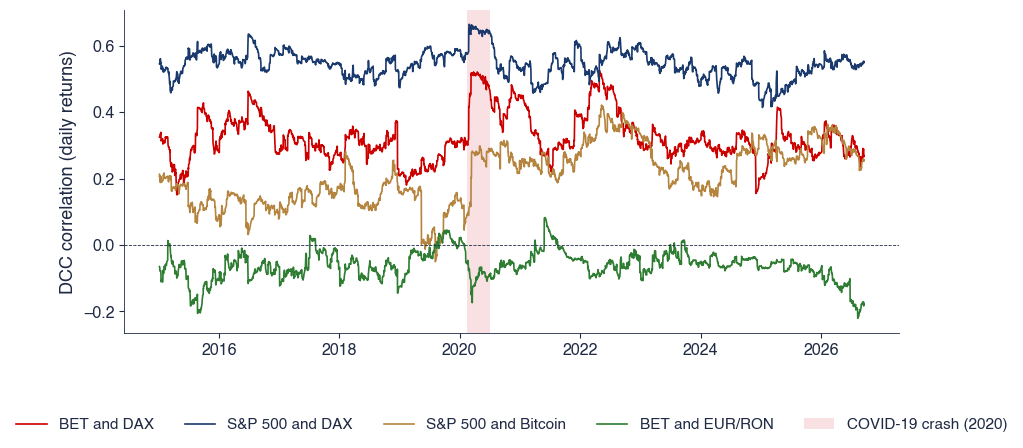

{'a': 0.00880008500557167, 'b': 0.9782016379796639, 'lr': 88.51340714272578, 'n': 2815}
{'async_sp500_bet': {'daily': 0.32397054149974697, 'weekly': 0.4571593417376745}, 'async_sp500_dax': {'daily': 0.555729969931501, 'weekly': 0.6816500358797717}, 'async_bet_dax': {'daily': 0.41908258709105733, 'weekly': 0.4729867822409048}}


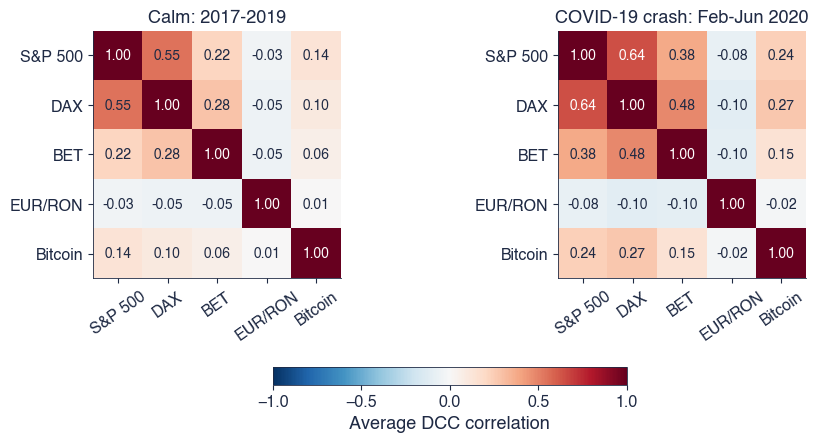

{'calm_avg': 0.12105823347312898, 'crisis_avg': 0.1861965292327025, 'nc': 89, 'bet_dax': {'calm': 0.2835469802790324, 'crisis': 0.4817733474164874}, 'sp500_dax': {'calm': 0.5466033245614882, 'crisis': 0.6417120825007955}, 'sp500_btc': {'calm': 0.13711264873487125, 'crisis': 0.24090021412207746}, 'bet_eurron': {'calm': -0.05012835928910351, 'crisis': -0.09593155755421726}, 'dax_btc': {'calm': 0.097858184621262, 'crisis': 0.26807389447533747}, 'sp500_bet': {'calm': 0.21586633320652676, 'crisis': 0.3796774191783407}}


In [11]:
def dcc_panel():
    R = common_returns(PANEL, PANEL_START)
    P, S, Z = step1(R)
    f = dcc_fit(Z.values)
    Rt = dcc_path(Z.values, f['a'], f['b'], f['Qbar'])
    return R, P, S, Z, f, Rt


def fig_panel_corr(save_it=True):
    R, P, S, Z, f, Rt = dcc_panel()
    idx = {k: i for i, k in enumerate(PANEL)}
    pairs = [('bet', 'dax'), ('sp500', 'dax'), ('sp500', 'btc'), ('bet', 'eurron')]
    cols = [st.IDAred, st.MainBlue, st.Amber, st.Forest]
    fig, ax = plt.subplots(figsize=(10, 4.2))
    out = dict(a=f['a'], b=f['b'], se_a=f['se_a'], se_b=f['se_b'], ab=f['a'] + f['b'], hl=half_life(f['a'] + f['b']),
               lr=f['lr'], n=len(R), first=str(R.index[0].date()), last=str(R.index[-1].date()),
               garch={k: dict(P[k], pers=P[k]['alpha'] + P[k]['beta']) for k in PANEL})
    W = weekly_returns(PANEL)
    for x, y in [('sp500', 'bet'), ('sp500', 'dax'), ('bet', 'dax')]:
        out[f'async_{x}_{y}'] = dict(daily=float(R[x].corr(R[y])), weekly=float(W[x].corr(W[y])))
    for (x, y), c in zip(pairs, cols):
        s = pd.Series(Rt[:, idx[x], idx[y]], index=R.index)
        ax.plot(s.index, s, color=c, lw=1.2, label=f'{NAME[x]} and {NAME[y]}')
        out[f'{x}_{y}'] = dict(mean=float(s.mean()), min=float(s.min()), max=float(s.max()), dmax=str(s.idxmax().date()),
                               dmin=str(s.idxmin().date()), last=float(s.iloc[-1]), qbar=float(f['Qbar'][idx[x], idx[y]]))
    ax.axvspan(pd.Timestamp(PANEL_CRISIS[0]), pd.Timestamp(PANEL_CRISIS[1]), color=st.Crimson, alpha=0.15, lw=0,
               label='COVID-19 crash (2020)')
    ax.axhline(0, color=st.DarkText, lw=0.6, ls='--')
    ax.set_ylabel('DCC correlation (daily returns)')
    st.legend_outside_bottom(ax, ncol=5)
    save('tsa_ch14_panel_corr', save_it)
    return out


def fig_panel_heatmap(save_it=True):
    R, P, S, Z, f, Rt = dcc_panel()
    T = pd.Series(range(len(R)), index=R.index)
    calm = Rt[T.loc[CALM[0]:CALM[1]].values].mean(axis=0)
    cris = Rt[T.loc[PANEL_CRISIS[0]:PANEL_CRISIS[1]].values].mean(axis=0)
    labs = [NAME[k] for k in PANEL]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
    for ax, M, t in zip(axes, (calm, cris), ('Calm: 2017-2019', 'COVID-19 crash: Feb-Jun 2020')):
        im = ax.imshow(M, cmap='RdBu_r', vmin=-1, vmax=1)
        ax.set_xticks(range(5))
        ax.set_xticklabels(labs, rotation=35)
        ax.set_yticks(range(5))
        ax.set_yticklabels(labs)
        for i in range(5):
            for j in range(5):
                ax.text(j, i, f'{M[i, j]:.2f}', ha='center', va='center', fontsize=10,
                        color='white' if abs(M[i, j]) > 0.6 else st.DarkText)
        ax.set_title(t)
    fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.05, pad=0.25, label='Average DCC correlation')
    save('tsa_ch14_panel_heatmap', save_it)
    idx = {k: i for i, k in enumerate(PANEL)}
    off = ~np.eye(5, dtype=bool)
    out = dict(calm_avg=float(calm[off].mean()), crisis_avg=float(cris[off].mean()), nc=int(len(T.loc[PANEL_CRISIS[0]:PANEL_CRISIS[1]])))
    for x, y in [('bet', 'dax'), ('sp500', 'dax'), ('sp500', 'btc'), ('bet', 'eurron'), ('dax', 'btc'), ('sp500', 'bet')]:
        out[f'{x}_{y}'] = dict(calm=float(calm[idx[x], idx[y]]), crisis=float(cris[idx[x], idx[y]]))
    return out


p = fig_panel_corr(save_it=False)
print({k: p[k] for k in ('a', 'b', 'lr', 'n')})
print({k: v for k, v in p.items() if k.startswith('async')})
print(fig_panel_heatmap(save_it=False))

## 5. Portfolio VaR 1% and backtesting

- Parameters estimated on 2000–2014; the filters run on 2015–2026 without re-estimation.

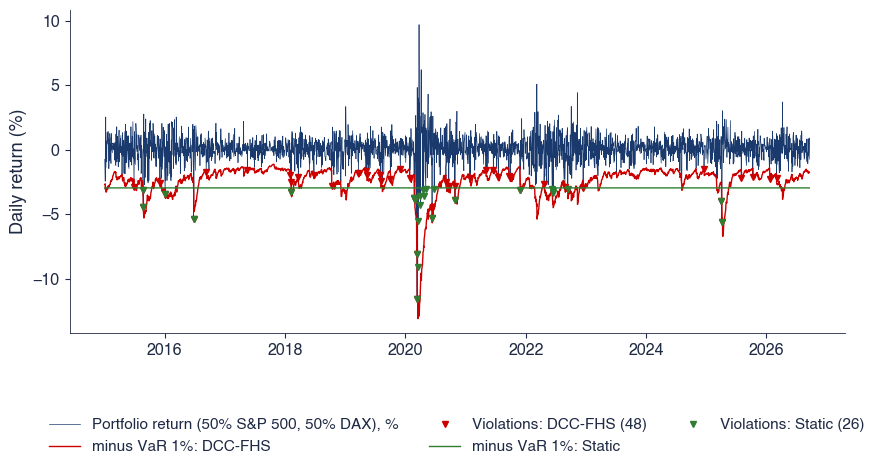

         violations    rate  Kupiec p  independence p
DCC            65.0  0.0225    0.0000          0.0035
DCC-FHS        48.0  0.0166    0.0011          0.0084
CCC            57.0  0.0197    0.0000          0.0300
Static         26.0  0.0090    0.5775          0.0013


In [12]:
def kupiec(viol, alpha=ALPHA_VAR):
    """Kupiec (1995) unconditional coverage test: LR = -2 log[(1-a)^(n-x) a^x / ((1-p)^(n-x) p^x)], chi2(1)."""
    n, x = len(viol), int(np.sum(viol))
    p = x / n
    l0 = (n - x) * np.log(1 - alpha) + x * np.log(alpha)
    l1 = (n - x) * np.log(1 - p) + (x * np.log(p) if x > 0 else 0.0)
    lr = -2 * (l0 - l1)
    return dict(n=n, x=x, rate=p, lr=float(lr), p=float(stats.chi2.sf(lr, 1)))


def christoffersen(viol):
    """Christoffersen (1998) independence test: does a violation today make a violation tomorrow more likely?
    LR = -2 log[L(pi) / L(pi01, pi11)], chi2(1)."""
    v = np.asarray(viol, int)
    a, b = v[:-1], v[1:]
    n00, n01 = np.sum((a == 0) & (b == 0)), np.sum((a == 0) & (b == 1))
    n10, n11 = np.sum((a == 1) & (b == 0)), np.sum((a == 1) & (b == 1))
    p01, p11 = n01 / max(n00 + n01, 1), n11 / max(n10 + n11, 1)
    p = (n01 + n11) / len(a)
    xl = lambda k, q: k * np.log(q) if k > 0 else 0.0
    l0 = xl(n00 + n10, 1 - p) + xl(n01 + n11, p)
    l1 = xl(n00, 1 - p01) + xl(n01, p01) + xl(n10, 1 - p11) + xl(n11, p11)
    lr = -2 * (l0 - l1)
    return dict(n11=int(n11), p01=float(p01), p11=float(p11), lr=float(lr), p=float(stats.chi2.sf(lr, 1)))


def portfolio_var():
    R = common_returns(['sp500', 'dax'], PAIR_START)
    P, S, Z = step1(R, fit_until=SPLIT)
    Zin = Z.loc[:SPLIT]
    f = dcc_fit(Zin.values)
    Rt = dcc_path(Z.values, f['a'], f['b'], f['Qbar'])
    w = np.array(WEIGHTS)
    mu = np.array([P[k]['mu'] for k in R.columns])
    s = S.values
    H = Rt * s[:, :, None] * s[:, None, :]
    sp_dcc = np.sqrt(np.einsum('i,tij,j->t', w, H, w))
    Rc = f['Qbar']                                             # CCC: constant correlation of step-1 residuals
    Hc = Rc[None] * s[:, :, None] * s[:, None, :]
    sp_ccc = np.sqrt(np.einsum('i,tij,j->t', w, Hc, w))
    sp_sta = float(np.sqrt(w @ np.cov(R.loc[:SPLIT].values.T) @ w))
    zq = stats.norm.ppf(ALPHA_VAR)
    rp = R.values @ w
    m = float(w @ mu)
    out_idx = R.index > SPLIT
    res = {'zq': float(zq), 'a': f['a'], 'b': f['b'], 'n_in': int((~out_idx).sum())}
    # filtered historical simulation: the 1% quantile of the in-sample standardised portfolio returns replaces z
    q_fhs = float(np.quantile(((rp - m) / sp_dcc)[~out_idx], ALPHA_VAR))
    res['q_fhs'] = q_fhs
    V = {'DCC': -(m + zq * sp_dcc), 'DCC-FHS': -(m + q_fhs * sp_dcc), 'CCC': -(m + zq * sp_ccc),
         'Static': -(m + zq * sp_sta) * np.ones(len(rp))}
    for k, v in V.items():
        res[k] = kupiec((rp < -v)[out_idx])
        res[k]['ind'] = christoffersen((rp < -v)[out_idx])
        res[k]['mean_var'] = float(v[out_idx].mean())
        res[k]['max_var'] = float(v[out_idx].max())
        for c, (a, b) in CRISES.items():
            if c == '2020':
                sel = (R.index >= a) & (R.index <= b)
                res[k]['viol2020'] = int(np.sum((rp < -v)[sel]))
    s_ = pd.Series
    return R.index, rp, {k: s_(v, index=R.index) for k, v in V.items()}, out_idx, res


def fig_var_backtest(save_it=True):
    idx, rp, V, out_idx, res = portfolio_var()
    rp = pd.Series(rp, index=idx).loc[idx[out_idx]]
    fig, ax = plt.subplots(figsize=(10, 4.2))
    ax.plot(rp.index, rp, color=st.MainBlue, lw=0.5, label='Portfolio return (50% S&P 500, 50% DAX), %')
    for k, c in (('DCC-FHS', st.IDAred), ('Static', st.Forest)):
        v = V[k].loc[rp.index]
        ax.plot(v.index, -v, color=c, lw=1.0, label=f'minus VaR 1%: {k}')
        hit = rp < -v
        ax.plot(rp.index[hit], rp[hit], 'v', color=c, ms=4, label=f'Violations: {k} ({int(hit.sum())})')
    ax.set_ylabel('Daily return (%)')
    st.legend_outside_bottom(ax, ncol=3)
    save('tsa_ch14_var_backtest', save_it)
    return res


v = fig_var_backtest(save_it=False)
print(pd.DataFrame({k: {'violations': v[k]['x'], 'rate': v[k]['rate'], 'Kupiec p': v[k]['p'], 'independence p': v[k]['ind']['p']} for k in ('DCC', 'DCC-FHS', 'CCC', 'Static')}).T.round(4))

## 6. Dynamic hedge ratios

- BET hedged with the DAX: DCC, rolling OLS and static OLS, out of sample.

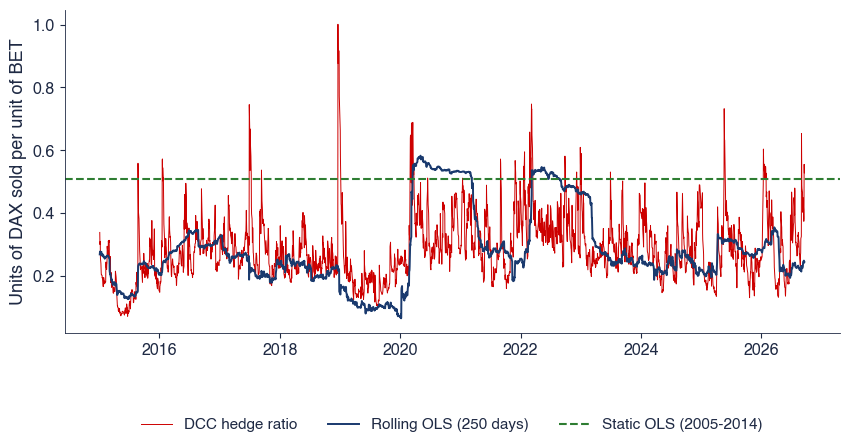

{'a': 0.0086, 'b': 0.9878, 'static': 0.5081, 'n_oos': 2893, 'first': '2015-01-05', 'dcc_min': 0.0711, 'dcc_max': 1.0012, 'dcc_mean': 0.2858, 'dcc_dmax': '2018-12-20', 'dcc_dmin': '2015-06-23', 'var_un': 0.9718, 'var_static': 0.8394, 'he_static': 0.1363, 'var_rolling': 0.797, 'he_rolling': 0.1799, 'var_dcc': 0.7859, 'he_dcc': 0.1913}


In [13]:
def hedge():
    R = common_returns(['bet', 'dax'], HEDGE_START)
    P, S, Z = step1(R, fit_until=SPLIT)
    f = dcc_fit(Z.loc[:SPLIT].values)
    Rt = dcc_path(Z.values, f['a'], f['b'], f['Qbar'])
    h_dcc = pd.Series(Rt[:, 0, 1] * S['bet'] / S['dax'], index=R.index)          # cov / var = rho sigma_s / sigma_f
    ins = R.loc[:SPLIT]
    h_sta = float(np.cov(ins['bet'], ins['dax'])[0, 1] / ins['dax'].var())
    h_rol = (R['bet'].rolling(ROLL).cov(R['dax']) / R['dax'].rolling(ROLL).var()).shift(1)   # past data only
    oos = R.loc[R.index > SPLIT]
    hd, hr = h_dcc.loc[oos.index], h_rol.loc[oos.index]
    un = oos['bet']
    out = {'a': f['a'], 'b': f['b'], 'static': h_sta, 'n_oos': len(oos), 'first': str(oos.index[0].date()),
           'dcc_min': float(hd.min()), 'dcc_max': float(hd.max()), 'dcc_mean': float(hd.mean()),
           'dcc_dmax': str(hd.idxmax().date()), 'dcc_dmin': str(hd.idxmin().date()), 'var_un': float(un.var())}
    for k, h in (('static', h_sta), ('rolling', hr), ('dcc', hd)):
        e = un - h * oos['dax']
        out[f'var_{k}'] = float(e.var())
        out[f'he_{k}'] = float(1 - e.var() / un.var())
    return R, h_dcc, h_rol, h_sta, out


def fig_hedge(save_it=True):
    R, h_dcc, h_rol, h_sta, out = hedge()
    a = '2015-01-01'
    fig, ax = plt.subplots(figsize=(10, 4.2))
    ax.plot(h_dcc.loc[a:].index, h_dcc.loc[a:], color=st.IDAred, lw=0.7, label='DCC hedge ratio')
    ax.plot(h_rol.loc[a:].index, h_rol.loc[a:], color=st.MainBlue, lw=1.4, label='Rolling OLS (250 days)')
    ax.axhline(h_sta, color=st.Forest, lw=1.5, ls='--', label='Static OLS (2005-2014)')
    ax.set_ylabel('Units of DAX sold per unit of BET')
    st.legend_outside_bottom(ax, ncol=3)
    save('tsa_ch14_hedge', save_it)
    return out


h = fig_hedge(save_it=False)
print({k: round(v, 4) if isinstance(v, float) else v for k, v in h.items()})

## Exercises

1. Re-estimate the S&P 500 and DAX DCC on weekly returns (`weekly_returns(['sp500', 'dax'], '2000-01-01')`): how do $a$, $b$ and the mean correlation change?
2. Replace the Normal quantile of the VaR by the quantile of a Student $t$ distribution with 5 degrees of freedom (scaled to unit variance) and repeat the Kupiec test.
3. Hedge the BET with the S&P 500 instead of the DAX: compare the hedging effectiveness and explain the difference with the asynchronous closes.